# DARMANIS Pre-Processing
## 1. Imports and Set-Up:

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
dir = './data/'

counts_fp = "GBM_raw_gene_counts.csv"
meta_fp = "GBM_metadata.csv"
out_csv = "GBM_HVG500_with_metadata.csv"
out_h5ad = "GBM_HVG500_scanpy.h5ad"

## 2. Handle Data:

Read data:

In [4]:
counts = pd.read_csv(f"{dir}{counts_fp}", sep=r"\s+")

print(f'counts.shape: {counts.shape} \n')
print(f'genes: {counts.index} \n')
print(f'cell IDs: {counts.columns} \n')

counts.shape: (23368, 3589) 

genes: Index(['1/2-SBSRNA4', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2LD1', 'A2M', 'A2ML1',
       'A2MP1', 'A4GALT', 'A4GNT',
       ...
       'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1',
       'ZZZ3', 'tAKR'],
      dtype='object', length=23368) 

cell IDs: Index(['1001000173.G8', '1001000173.D4', '1001000173.B4', '1001000173.A2',
       '1001000173.E2', '1001000173.F6', '1001000173.B12', '1001000173.D6',
       '1001000173.H1', '1001000173.E4',
       ...
       '1001000271.C2', '1001000271.D1', '1001000271.B1', '1001000271.A3',
       '1001000271.E1', '1001000271.F1', '1001000271.D4', '1001000271.C1',
       '1001000271.H7', '1001000271.H2'],
      dtype='object', length=3589) 



Create AnnData object:

In [5]:
adata = sc.AnnData(counts.T)
adata.var_names = counts.index
adata.obs_names = counts.columns

## 3. Handle Meta-Data:

Load meta-data:

In [6]:
meta = pd.read_csv(f"{dir}{meta_fp}", sep=r"\s+")

print(f'meta.shape: {meta.shape} \n')

meta.head()

meta.shape: (3589, 29) 



,Sample.type,Selection,Location,Sample.name,Total_reads,Unique_reads,Unique_reads_percent,Splice_sites_total,Splice_sites_Annotated,Splice_sites_GT.AG,...,ERCC_to_non_ERCC,Genes_detected,housekeeping_cluster,housekeeping_cluster_color,Sample.type.color,Selection.color,Sample.name.color,Location.color,Cluster_2d,Cluster_2d_color
1001000173.G8,Glioblastoma,Unpanned,Tumor,BT_S2,1741039,1400382,80.43,126660,122397,125741,...,0.562454,1962,2,#AEC7E8,#1F77B4,#98DF8A,#AEC7E8,#FF7F0E,11,#8C564B
1001000173.D4,Glioblastoma,Unpanned,Tumor,BT_S2,1229919,1081271,87.91,106857,103763,105878,...,1.442474,515,2,#AEC7E8,#1F77B4,#98DF8A,#AEC7E8,#FF7F0E,2,#AEC7E8
1001000173.B4,Glioblastoma,Unpanned,Tumor,BT_S2,1483293,1301500,87.74,539234,531827,536121,...,0.058506,5607,2,#AEC7E8,#1F77B4,#98DF8A,#AEC7E8,#FF7F0E,11,#8C564B
1001000173.A2,Glioblastoma,Unpanned,Tumor,BT_S2,1943210,1678256,86.37,469261,457505,465354,...,0.151006,3856,2,#AEC7E8,#1F77B4,#98DF8A,#AEC7E8,#FF7F0E,11,#8C564B
1001000173.E2,Glioblastoma,Unpanned,Tumor,BT_S2,1968898,1656225,84.12,204141,195729,202753,...,0.350357,2173,2,#AEC7E8,#1F77B4,#98DF8A,#AEC7E8,#FF7F0E,11,#8C564B


Inspect columns; alter this if different meta-data is needed:

In [7]:
meta.columns

Index(['Sample.type', 'Selection', 'Location', 'Sample.name', 'Total_reads',
       'Unique_reads', 'Unique_reads_percent', 'Splice_sites_total',
       'Splice_sites_Annotated', 'Splice_sites_GT.AG', 'Splice_sites_GC.AG',
       'Splice_sites_AT.AC', 'Splice_sites_non_canonical',
       'Multimapping_reads_percent', 'Unmapped_mismatch', 'Unmapped_short',
       'Unmapped_other', 'ERCC_reads', 'Non_ERCC_reads', 'ERCC_to_non_ERCC',
       'Genes_detected', 'housekeeping_cluster', 'housekeeping_cluster_color',
       'Sample.type.color', 'Selection.color', 'Sample.name.color',
       'Location.color', 'Cluster_2d', 'Cluster_2d_color'],
      dtype='object')

In [8]:
# meta_selection = meta[["Sample.type", "Location"]]

meta_selection = meta.copy()

Make sure cell IDs align in the two data frames:

In [9]:
print(f'All cells included in meta data? \n{len(counts.columns) == len(meta_selection[meta_selection.index.isin(adata.obs_names)])} \n')

meta_selection = meta_selection.loc[adata.obs_names]

All cells included in meta data? 
True 



Attach to AnnData object:

In [10]:
adata.obs = meta_selection

## 4. Normalize and Select Highly-Variable Genes:

Either go with classic Seurat v2 method:

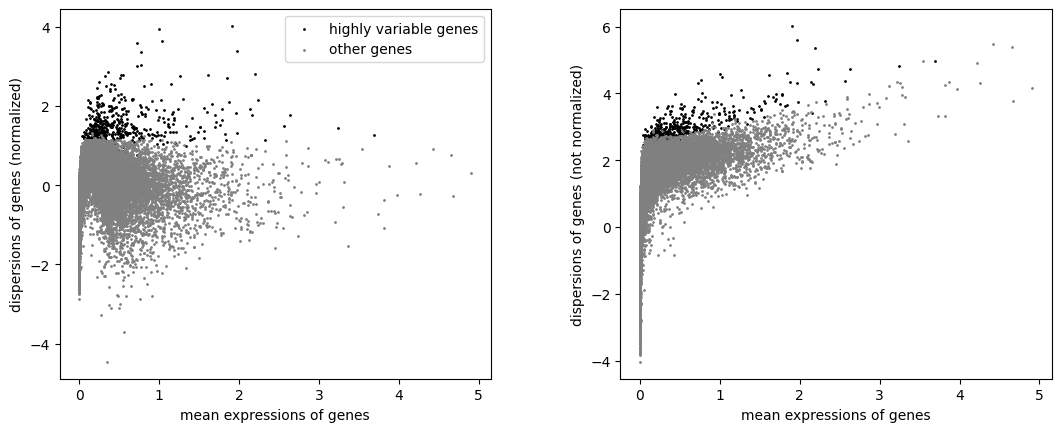

In [11]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat')
sc.pl.highly_variable_genes(adata)

Or use Seurat v3 method (uses mean-variance relationship; assumes integer counts):

In [12]:
# sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat_v3')
# sc.pl.highly_variable_genes(adata)

Subset to HVGs only:

In [13]:
adata = adata[:, adata.var["highly_variable"]].copy()

## 5. Export:

In [14]:
X = pd.DataFrame(
    adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
    index=adata.obs_names,
    columns=adata.var_names
)

X = pd.concat([adata.obs, X], axis=1)
X

,Sample.type,Selection,Location,Sample.name,Total_reads,Unique_reads,Unique_reads_percent,Splice_sites_total,Splice_sites_Annotated,Splice_sites_GT.AG,...,ZNF436,ZNF45,ZNF460,ZNF498,ZNF544,ZNF597,ZNF607,ZNF627,ZNF708,ZNF844
1001000173.G8,Glioblastoma,Unpanned,Tumor,BT_S2,1741039,1400382,80.43,126660,122397,125741,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.137946
1001000173.D4,Glioblastoma,Unpanned,Tumor,BT_S2,1229919,1081271,87.91,106857,103763,105878,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1001000173.B4,Glioblastoma,Unpanned,Tumor,BT_S2,1483293,1301500,87.74,539234,531827,536121,...,0.264236,0.0,0.000000,0.593921,0.000000,0.000000,0.05353,0.210018,0.027123,0.000000
1001000173.A2,Glioblastoma,Unpanned,Tumor,BT_S2,1943210,1678256,86.37,469261,457505,465354,...,0.000000,0.0,0.737726,0.000000,0.846762,0.000000,0.00000,0.000000,0.000000,0.000000
1001000173.E2,Glioblastoma,Unpanned,Tumor,BT_S2,1968898,1656225,84.12,204141,195729,202753,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001000271.F1,Glioblastoma,Neurons(Thy1),Tumor,BT_S6,1659951,1244006,74.94,84114,83285,83244,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1001000271.D4,Glioblastoma,Neurons(Thy1),Tumor,BT_S6,1565934,982579,62.75,170616,168401,170022,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1001000271.C1,Glioblastoma,Neurons(Thy1),Tumor,BT_S6,2206209,1572660,71.28,325277,319056,323144,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1001000271.H7,Glioblastoma,Neurons(Thy1),Tumor,BT_S6,8923,5331,59.74,697,688,691,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


In [15]:
X.to_csv(f"{dir}GBM_HVG500_with_metadata.csv")

---